# PlantVillage Classification with Pure CNN

This notebook implements a pure CNN (no pretrained models) for classifying PlantVillage dataset.

**Key Features:**
- Pure CNN architecture (no ResNet, VGG, etc.)
- Data augmentation to prevent overfitting
- Early stopping and learning rate scheduling
- Data balancing with weighted sampling
- Target: >90% validation accuracy

In [10]:
# PlantVillage with pure CNN

import io
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [11]:
# -----------------------------
# 1) Reproducibility and device
# -----------------------------

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Performance knobs for GPU training speed
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.set_float32_matmul_precision("high")

# AMP for GPU
USE_AMP = device.type == "cuda"
if USE_AMP:
    from torch.amp import autocast, GradScaler

    scaler = GradScaler("cuda")
    print("Mixed precision (AMP) enabled")

Device: cuda
Mixed precision (AMP) enabled


In [13]:
# -----------------------------
# 2) Load PlantVillage dataset
# -----------------------------

from datasets import (
    load_dataset,
    get_dataset_config_names,
    ClassLabel,
    Image as HFImage,
)

HF_DATASET_NAME = "BrandonFors/Plant-Diseases-PlantVillage-Dataset"
PREFERRED_CONFIG = "default"

available_configs = get_dataset_config_names(HF_DATASET_NAME)
print(f"Available configs: {available_configs}")

if PREFERRED_CONFIG in available_configs:
    HF_DATASET_CONFIG = PREFERRED_CONFIG
elif "default" in available_configs:
    HF_DATASET_CONFIG = "default"
else:
    HF_DATASET_CONFIG = available_configs[0] if available_configs else None

if HF_DATASET_CONFIG is None:
    raise ValueError("No available dataset config found")

print(
    f"Loading PlantVillage dataset from Hugging Face: {HF_DATASET_NAME} ({HF_DATASET_CONFIG})..."
)

# Prefer predefined evaluation split to reduce leakage risk
ds = load_dataset(HF_DATASET_NAME, HF_DATASET_CONFIG)

if "train" in ds and "test" in ds:
    train_dataset = ds["train"]
    val_dataset = ds["test"]
elif "train" in ds and "validation" in ds:
    train_dataset = ds["train"]
    val_dataset = ds["validation"]
elif "train" in ds:
    # Fallback only if dataset has no eval split
    split = ds["train"].train_test_split(test_size=0.2, seed=SEED)
    train_dataset = split["train"]
    val_dataset = split["test"]
else:
    raise ValueError("Dataset must contain a train split")

feature_map = train_dataset.features
feature_keys = list(feature_map.keys())

# Infer image/label columns to avoid hard-coded schema assumptions
if "image" in feature_map:
    image_col = "image"
else:
    image_name_candidates = [
        k for k in feature_keys if ("image" in k.lower() or "img" in k.lower())
    ]
    image_type_candidates = [
        k for k in feature_keys if isinstance(feature_map[k], HFImage)
    ]
    sample0 = train_dataset[0]
    image_value_candidates = [
        k
        for k in feature_keys
        if isinstance(sample0.get(k), (Image.Image, np.ndarray, dict, str))
    ]
    merged_candidates = (
        image_name_candidates + image_type_candidates + image_value_candidates
    )
    image_col = next((k for k in merged_candidates if k in feature_keys), None)
    if image_col is None:
        raise ValueError(
            f"Cannot find an image column. Available columns: {feature_keys}"
        )

if "label" in feature_map:
    label_col = "label"
elif "labels" in feature_map:
    label_col = "labels"
else:
    classlabel_candidates = [
        k for k in feature_keys if isinstance(feature_map[k], ClassLabel)
    ]
    label_name_candidates = [
        k for k in feature_keys if ("label" in k.lower() or "class" in k.lower())
    ]
    merged_label_candidates = classlabel_candidates + label_name_candidates
    label_col = next((k for k in merged_label_candidates if k in feature_keys), None)
    if label_col is None:
        raise ValueError(
            f"Cannot find a label column. Available columns: {feature_keys}"
        )

label_feature = train_dataset.features[label_col]
if isinstance(label_feature, ClassLabel):
    class_names = label_feature.names
else:
    unique_labels = sorted({int(sample[label_col]) for sample in train_dataset})
    class_names = [str(x) for x in unique_labels]

num_classes = len(class_names)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation/Test samples: {len(val_dataset)}")
print(f"Features: {train_dataset.features}")
print(f"Using image column: {image_col}")
print(f"Using label column: {label_col}")
print(f"Detected classes: {num_classes}")

Available configs: ['default']
Loading PlantVillage dataset from Hugging Face: BrandonFors/Plant-Diseases-PlantVillage-Dataset (default)...


Generating test split: 100%|██████████| 10849/10849 [00:00<00:00, 22207.77 examples/s]


Train samples: 43456
Validation/Test samples: 10849
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_b


Class distribution (train):
  0: Apple___Apple_scab - 504
  1: Apple___Black_rot - 497
  2: Apple___Cedar_apple_rust - 220
  3: Apple___healthy - 1316
  4: Blueberry___healthy - 1202
  5: Cherry_(including_sour)___Powdery_mildew - 842
  6: Cherry_(including_sour)___healthy - 684
  7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot - 411
  8: Corn_(maize)___Common_rust_ - 954
  9: Corn_(maize)___Northern_Leaf_Blight - 788
  10: Corn_(maize)___healthy - 930
  11: Grape___Black_rot - 944
  12: Grape___Esca_(Black_Measles) - 1107
  13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) - 861
  14: Grape___healthy - 339
  15: Orange___Haunglongbing_(Citrus_greening) - 4406
  16: Peach___Bacterial_spot - 1838
  17: Peach___healthy - 288
  18: Pepper,_bell___Bacterial_spot - 798
  19: Pepper,_bell___healthy - 1183
  20: Potato___Early_blight - 800
  21: Potato___Late_blight - 800
  22: Potato___healthy - 122
  23: Raspberry___healthy - 297
  24: Soybean___healthy - 4072
  25: Squash___Powdery_mil

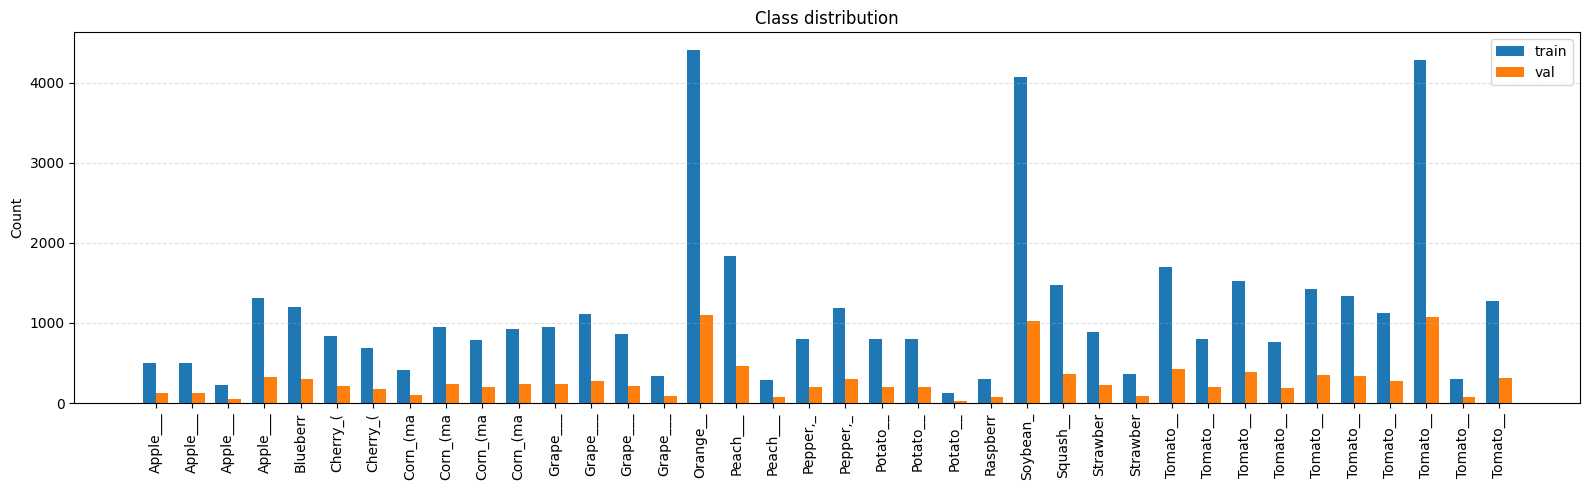

In [14]:
# -----------------------------
# 3) Data analysis
# -----------------------------

train_labels = [int(sample[label_col]) for sample in train_dataset]
val_labels = [int(sample[label_col]) for sample in val_dataset]

train_counts = np.bincount(train_labels, minlength=num_classes)
val_counts = np.bincount(val_labels, minlength=num_classes)

print("\nClass distribution (train):")
for i, name in enumerate(class_names):
    print(f"  {i}: {name} - {train_counts[i]}")

# Plot
plt.figure(figsize=(16, 5))
x = np.arange(len(class_names))
w = 0.35
plt.bar(x - w / 2, train_counts, width=w, label="train")
plt.bar(x + w / 2, val_counts, width=w, label="val")
plt.xticks(x, [c[:8] for c in class_names], rotation=90)
plt.ylabel("Count")
plt.title("Class distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 4) Transform
# -----------------------------

IMG_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = min(8, os.cpu_count() or 2) if device.type == "cuda" else 0
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

val_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

print(f"NUM_WORKERS={NUM_WORKERS}, PERSISTENT_WORKERS={PERSISTENT_WORKERS}")

In [ ]:
# -----------------------------
# 5) Custom Dataset class
# -----------------------------


class PlantVillageDS(Dataset):
    def __init__(self, hf_dataset, image_col, label_col, transform=None):
        self.hf_dataset = hf_dataset
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    @staticmethod
    def _to_pil_image(raw_image):
        if isinstance(raw_image, Image.Image):
            return raw_image
        if isinstance(raw_image, np.ndarray):
            return Image.fromarray(raw_image)
        if isinstance(raw_image, str):
            return Image.open(raw_image)
        if isinstance(raw_image, dict):
            if raw_image.get("bytes") is not None:
                return Image.open(io.BytesIO(raw_image["bytes"]))
            if raw_image.get("path") is not None:
                return Image.open(raw_image["path"])
        raise TypeError(f"Unsupported image format: {type(raw_image)}")

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = self._to_pil_image(sample[self.image_col])
        label = int(sample[self.label_col])

        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


train_ds = PlantVillageDS(
    train_dataset, image_col=image_col, label_col=label_col, transform=train_tfms
)
val_ds = PlantVillageDS(
    val_dataset, image_col=image_col, label_col=label_col, transform=val_tfms
)

In [ ]:
# -----------------------------
# 6) Data balancing
# -----------------------------

train_labels_array = np.array(train_labels)
class_sample_count = np.bincount(train_labels_array, minlength=num_classes)
class_weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = class_weights[train_labels_array]
sample_weights = torch.from_numpy(sample_weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)
if NUM_WORKERS > 0:
    train_loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS
    train_loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

val_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)
if NUM_WORKERS > 0:
    val_loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS
    val_loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(train_ds, **train_loader_kwargs)
val_loader = DataLoader(val_ds, **val_loader_kwargs)

print("Data loaders prepared with weighted sampling for balancing")

In [ ]:
# -----------------------------
# 7) Pure CNN model
# -----------------------------


class PlantVillageCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 128x128 -> 64x64
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            # Block 2: 64x64 -> 32x32
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
            # Block 3: 32x32 -> 16x16
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4),
            # Block 4: 16x16 -> 8x8
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = PlantVillageCNN(num_classes=num_classes).to(device)
if device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

# torch.compile can improve steady-state throughput on supported builds
USE_COMPILE = device.type == "cuda" and hasattr(torch, "compile")
if USE_COMPILE:
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("torch.compile enabled")
    except Exception as e:
        print(f"torch.compile unavailable, fallback to eager mode: {e}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# -----------------------------
# 8) Training loop
# -----------------------------

EPOCHS = 50
PATIENCE = 10
best_val_acc = 0.0
best_state = None
no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


def run_one_epoch(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            if USE_AMP:
                with autocast("cuda"):
                    logits = model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(images)
                loss = criterion(logits, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                optimizer.step()
        else:
            with torch.inference_mode():
                if USE_AMP:
                    with autocast("cuda"):
                        logits = model(images)
                        loss = criterion(logits, labels)
                else:
                    logits = model(images)
                    loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = correct / max(total, 1)
    return epoch_loss, epoch_acc


for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

In [ ]:
# -----------------------------
# 9) Evaluation
# -----------------------------

val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)
print(f"\nBest/Final validation accuracy: {val_acc*100:.2f}%")

# Confusion matrix
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (first 10 classes):")
print(cm[:10, :10])

precision = np.diag(cm) / np.maximum(cm.sum(axis=0), 1)
recall = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-8)

print("\nPer-class F1 (first 10):")
for i in range(min(10, num_classes)):
    print(
        f"  {class_names[i]}: P={precision[i]:.4f}, R={recall[i]:.4f}, F1={f1[i]:.4f}"
    )

In [ ]:
# -----------------------------
# 10) Plot training history
# -----------------------------

epochs_ran = len(history["train_loss"])
x = np.arange(1, epochs_ran + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history["train_loss"], label="train loss")
plt.plot(x, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(x, np.array(history["train_acc"]) * 100, label="train acc")
plt.plot(x, np.array(history["val_acc"]) * 100, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 11) Save model
# -----------------------------

save_path = "plantvillage_pure_cnn_best.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved best model to: {save_path}")

if val_acc >= 0.90:
    print("Target reached: validation accuracy >= 90%")
else:
    print("Validation accuracy < 90%. Consider tuning hyperparameters.")

## Summary

This notebook demonstrates:
1. **Pure CNN Architecture**: Custom CNN with no pretrained models
2. **PlantVillage Dataset**: 38 classes of plant diseases
3. **Anti-overfitting Techniques**:
   - Data augmentation (RandomHorizontalFlip, RandomRotation, ColorJitter, RandomAffine)
   - Dropout (0.5, 0.4, 0.3, 0.2)
   - Batch normalization
   - Weight decay (L2 regularization)
   - Early stopping
   - Learning rate scheduling
   - Gradient clipping
4. **Data Balancing**: WeightedRandomSampler
5. **Target**: Achieve >90% validation accuracy